# 🛒 Bangla Daraz Review Analytics & ABSA Platform
### Dual-Architecture Benchmark: TF-IDF vs. BanglaBERT for Aspect-Based Sentiment Analysis

This notebook provides a complete interactive workflow for:
1. **Bangla Text Preprocessing** (Unicode cleaning, punctuation stripping, stopword removal)
2. **ABSA Composite Label Parsing** (Sentiment derivation and Aspect/Issue extraction)
3. **Dual-Architecture Modeling**:
   - **Model Family 1**: Hybrid TF-IDF (Word (1,2) + Char (3,5) N-Gram Union) + Logistic Regression
   - **Model Family 2**: Contextual BanglaBERT (`sagorsarker/bangla-bert-base`) 768-dim embeddings + Logistic Regression
4. **Tasks Evaluated**:
   - **Sentiment Analysis**: 3-Class Classification (`Positive`, `Negative`, `Neutral`)
   - **Aspect & Issue Detection**: Multi-label classification (5 Aspects: *Product Quality, Price, Delivery, Packaging, Seller Service*) with complaint flagging
5. **Comparative Benchmark Analysis & Interactive Review Tester**

## 1. Setup & Modular Imports

In [1]:
import sys
from pathlib import Path

# Auto-reload external modules and add project root to sys.path
%load_ext autoreload
%autoreload 2

BASE_DIR = Path.cwd().resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.config import (
    ALL_ASPECTS,
    SENTIMENT_LABELS,
    MODELS_CACHE,
    RESULTS_DIR,
    ensure_dirs
)
from src.preprocessing import clean_text, load_bangla_stopwords
from src.data_processing import (
    load_annotated_data,
    get_sentiment_split,
    get_aspect_split
)
from src.embeddings import get_or_cache_bert_features, get_bert_features
from src.models import (
    train_sentiment_tfidf,
    train_sentiment_bert,
    predict_sentiment,
    train_issue_tfidf,
    train_issue_bert,
    predict_issue,
    save_artifacts
)
from src.evaluation import (
    plot_and_save_confusion_matrix,
    save_classification_report_csv,
    save_model_comparison_csv,
    save_metrics_summary_json
)

ensure_dirs()
print('✓ Modular libraries loaded successfully!')

/home/shuvo/Documents/NLP_Project/.nlp_venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Modular libraries loaded successfully!


## 2. Bangla Text Preprocessing Demonstration

In [2]:
sample_raw = """
অসাধারণ প্রোডাক্ট! 👍👍 ডেলিভারিও খুব ফাস্ট ছিল... 
কিন্তু https://daraz.com.bd থেকে কেনার পর প্যাকেজিংটা একটু ছেঁড়া ছিল (order #123456)!! 
"""

print("--- RAW INPUT ---")
print(sample_raw)

print("--- PREPROCESSED OUTPUT ---")
print(clean_text(sample_raw))

stopwords = load_bangla_stopwords()
print(f"\n✓ Loaded {len(stopwords)} curated Bangla stopwords.")

--- RAW INPUT ---

অসাধারণ প্রোডাক্ট! 👍👍 ডেলিভারিও খুব ফাস্ট ছিল... 
কিন্তু https://daraz.com.bd থেকে কেনার পর প্যাকেজিংটা একটু ছেঁড়া ছিল (order #123456)!! 

--- PREPROCESSED OUTPUT ---
অসাধারণ প্রোডাক্ট ডেলিভারিও খুব ফাস্ট কেনার প্যাকেজিংটা ছেঁড়া 123456

✓ Loaded 142 curated Bangla stopwords.


## 3. Dataset Loading & Exploratory Data Analysis (EDA)

In [3]:
anno_df = load_annotated_data()
print(f"✓ Loaded {len(anno_df):,} expert-annotated Bangla reviews.")
anno_df[["original_text", "cleaned_text", "sentiment", "aspects_str", "issue_aspects_str"]].head(5)

✓ Loaded 2,016 expert-annotated Bangla reviews.


,original_text,cleaned_text,sentiment,aspects_str,issue_aspects_str
0,খুব ভালো একটি প্রোডাক্ট । ভালো সাউন্ড কোয়ালিটি...,খুব ভালো প্রোডাক্ট ভালো সাউন্ড কোয়ালিটি চার্জ...,Positive,Product Quality,NaN
1,নষ্ট প্রোডাক্ট দিছে। বক্সে চার্জ হয় কিন্তু বার...,নষ্ট প্রোডাক্ট দিছে বক্সে চার্জ হয় বার্ডে চার...,Negative,Packaging;Product Quality,Packaging;Product Quality
2,আলহামদুলিল্লাহ্। যেমন চেয়েছি তেমনই পেয়েছি \n...,আলহামদুলিল্লাহ্ চেয়েছি তেমনই পেয়েছি ডেলিভারি...,Positive,Delivery;Product Quality,NaN
3,খুবই ভালো এ দামের ভিতরে এর চেয়ে বেশি আশা করা ...,খুবই ভালো এ দামের ভিতরে এর চেয়ে আশা যায় সাউন...,Positive,Price;Product Quality,NaN
4,এই পন্য টা মোটামুটি ভালো কিন্তু ব্যটারি বেকাপ ...,পন্য টা মোটামুটি ভালো ব্যটারি বেকাপ ভালো সাউন্...,Neutral,Product Quality,NaN


/tmp/ipykernel_142180/3828638064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=anno_df, x="sentiment", order=SENTIMENT_LABELS, palette=["#EF4444", "#F59E0B", "#10B981"], ax=axes[0])


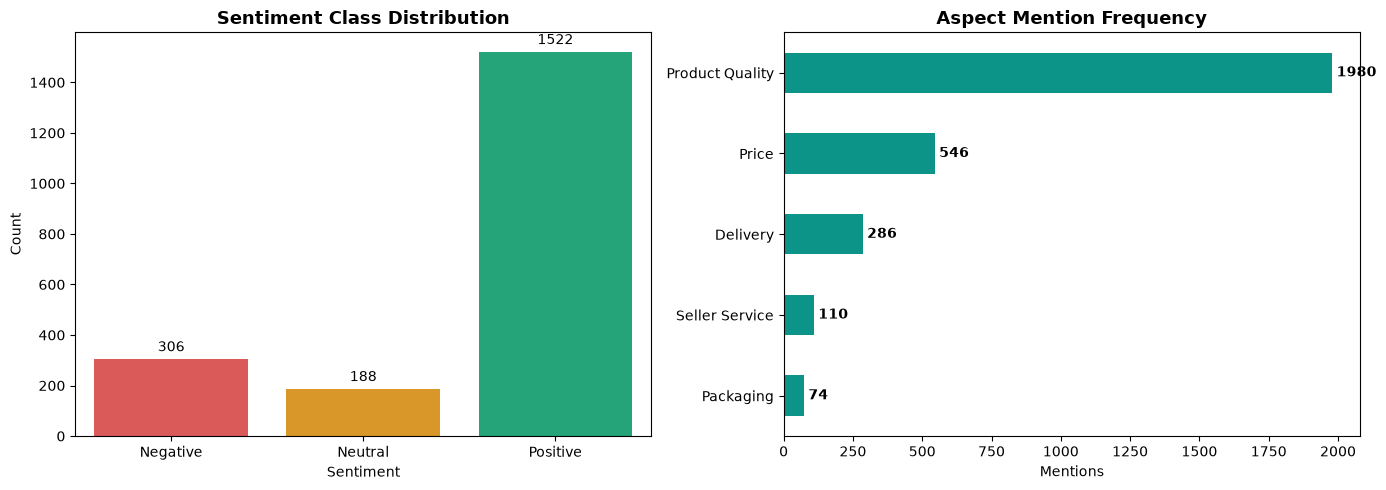

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Sentiment Distribution
sns.countplot(data=anno_df, x="sentiment", order=SENTIMENT_LABELS, palette=["#EF4444", "#F59E0B", "#10B981"], ax=axes[0])
axes[0].set_title("Sentiment Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

# 2. Aspect Mentions
aspect_counts = {}
for aspects_list in anno_df["aspects"]:
    for asp in aspects_list:
        aspect_counts[asp] = aspect_counts.get(asp, 0) + 1
asp_series = pd.Series(aspect_counts).sort_values(ascending=True)
asp_series.plot(kind="barh", color="#0D9488", ax=axes[1])
axes[1].set_title("Aspect Mention Frequency", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Mentions")
for i, v in enumerate(asp_series):
    axes[1].text(v + 15, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Train / Test Data Splitting (80/20 Stratified)

In [5]:
X_train_s, X_test_s, y_train_s, y_test_s = get_sentiment_split(anno_df)
print(f"✓ Sentiment Split: {len(X_train_s):,} train | {len(X_test_s):,} test")

X_train_a, X_test_a, y_train_a, y_test_a = get_aspect_split(anno_df)
print(f"✓ Aspect Split:    {len(X_train_a):,} train | {len(X_test_a):,} test")

✓ Sentiment Split: 1,612 train | 404 test
✓ Aspect Split:    1,612 train | 404 test


## 5. Model Family 1: TF-IDF (Word + Character N-Gram Union)

In [6]:
# 5.1 Sentiment Analysis (TF-IDF)
s_model_tfidf, s_vec_tfidf, s_metrics_tfidf = train_sentiment_tfidf(X_train_s, y_train_s, X_test_s, y_test_s)
save_artifacts("sentiment", s_model_tfidf, s_vec_tfidf, model_type="tfidf")
plot_and_save_confusion_matrix(y_test_s, s_metrics_tfidf["predictions"], SENTIMENT_LABELS, "Sentiment CM (TF-IDF)", "sentiment_tfidf.png")
save_classification_report_csv(s_metrics_tfidf["report"], "sentiment_tfidf.csv")
print(f"✓ [TF-IDF] Sentiment Accuracy: {s_metrics_tfidf['accuracy']:.4f} | Macro-F1: {s_metrics_tfidf['macro_f1']:.4f}")

# 5.2 Aspect Detection (TF-IDF)
a_model_tfidf, a_vec_tfidf, a_bin_tfidf, a_metrics_tfidf = train_issue_tfidf(X_train_a, y_train_a, X_test_a, y_test_a)
save_artifacts("issue", a_model_tfidf, a_vec_tfidf, a_bin_tfidf, model_type="tfidf")
save_classification_report_csv(a_metrics_tfidf["report"], "issue_tfidf.csv")
print(f"✓ [TF-IDF] Aspect Micro-F1: {a_metrics_tfidf['micro_f1']:.4f} | Macro-F1: {a_metrics_tfidf['macro_f1']:.4f} | Hamming Loss: {a_metrics_tfidf['hamming_loss']:.4f}")

✓ [TF-IDF] Sentiment Accuracy: 0.8762 | Macro-F1: 0.7747
✓ [TF-IDF] Aspect Micro-F1: 0.9345 | Macro-F1: 0.7804 | Hamming Loss: 0.0366


## 6. Model Family 2: Pretrained BanglaBERT Feature Extraction & Classifier

In [7]:
# Extract / Load cached 768-dim embeddings
print("Extracting / caching BanglaBERT embeddings...")
s_train_bert = get_or_cache_bert_features(X_train_s, MODELS_CACHE / "sentiment_train.npy")
s_test_bert = get_or_cache_bert_features(X_test_s, MODELS_CACHE / "sentiment_test.npy")
a_train_bert = get_or_cache_bert_features(X_train_a, MODELS_CACHE / "issue_train.npy")
a_test_bert = get_or_cache_bert_features(X_test_a, MODELS_CACHE / "issue_test.npy")

print(f"✓ Sentiment BERT shape: Train {s_train_bert.shape} | Test {s_test_bert.shape}")
print(f"✓ Aspect BERT shape:    Train {a_train_bert.shape} | Test {a_test_bert.shape}")

Extracting / caching BanglaBERT embeddings...
✓ Sentiment BERT shape: Train (1612, 768) | Test (404, 768)
✓ Aspect BERT shape:    Train (1612, 768) | Test (404, 768)


In [8]:
# 6.1 Sentiment Analysis (BanglaBERT)
s_model_bert, s_metrics_bert = train_sentiment_bert(s_train_bert, y_train_s, s_test_bert, y_test_s)
save_artifacts("sentiment", s_model_bert, model_type="bert")
plot_and_save_confusion_matrix(y_test_s, s_metrics_bert["predictions"], SENTIMENT_LABELS, "Sentiment CM (BanglaBERT)", "sentiment_bert.png")
save_classification_report_csv(s_metrics_bert["report"], "sentiment_bert.csv")
print(f"✓ [BanglaBERT] Sentiment Accuracy: {s_metrics_bert['accuracy']:.4f} | Macro-F1: {s_metrics_bert['macro_f1']:.4f}")

# 6.2 Aspect Detection (BanglaBERT)
a_model_bert, a_bin_bert, a_metrics_bert = train_issue_bert(a_train_bert, y_train_a, a_test_bert, y_test_a)
save_artifacts("issue", a_model_bert, binarizer=a_bin_bert, model_type="bert")
save_classification_report_csv(a_metrics_bert["report"], "issue_bert.csv")
print(f"✓ [BanglaBERT] Aspect Micro-F1: {a_metrics_bert['micro_f1']:.4f} | Macro-F1: {a_metrics_bert['macro_f1']:.4f} | Hamming Loss: {a_metrics_bert['hamming_loss']:.4f}")

✓ [BanglaBERT] Sentiment Accuracy: 0.8292 | Macro-F1: 0.6966
✓ [BanglaBERT] Aspect Micro-F1: 0.8797 | Macro-F1: 0.6501 | Hamming Loss: 0.0703


## 7. Comparative Benchmark Summary

In [9]:
comp_df = save_model_comparison_csv(
    s_metrics_tfidf,
    s_metrics_bert,
    a_metrics_tfidf,
    a_metrics_bert
)

metrics_summary = {
    "dataset_statistics": {
        "total_bangla_annotated_reviews": len(anno_df),
        "language": "bn",
        "sentiment_distribution": anno_df["sentiment"].value_counts().to_dict()
    },
    "sentiment_analysis": {
        "tfidf": s_metrics_tfidf["report"],
        "banglabert": s_metrics_bert["report"]
    },
    "aspect_detection": {
        "tfidf": a_metrics_tfidf["report"],
        "banglabert": a_metrics_bert["report"]
    }
}
save_metrics_summary_json(metrics_summary)

print("\n=================== 4-ROW BENCHMARK COMPARISON TABLE ===================")
display(comp_df)


=================== 4-ROW BENCHMARK COMPARISON TABLE ===================


,Task,Model,Accuracy,Macro F1,Weighted F1,Additional Metric
0,Sentiment Analysis,TF-IDF + Logistic Regression,0.8762,0.7747,0.8777,N/A
1,Sentiment Analysis,BanglaBERT + Logistic Regression,0.8292,0.6966,0.8322,N/A
2,Aspect Detection,TF-IDF + OneVsRest LogReg,0.9634,0.7804,0.9353,Hamming Loss: 0.0366
3,Aspect Detection,BanglaBERT + OneVsRest LogReg,0.9297,0.6501,0.8937,Hamming Loss: 0.0703


## 8. Live Multi-Task Inference Demo

In [10]:
test_reviews = [
    'প্রোডাক্ট খুব ভালো ছিল, ডেলিভারিও দ্রুত পেয়েছি। ধন্যবাদ।',
    'ডেলিভারি অনেক দেরি হয়েছে, প্রোডাক্টও বাজে কোয়ালিটি।',
    'সেলার ভালো ছিল কিন্তু প্যাকেজিং ভেঙে গেছে।',
    'দাম অনুযায়ী জিনিসটা একদম ভালো না।'
]

print('=' * 85)
print(f'{"Review Text":<45} | {"Sentiment (TF-IDF)":<18} | {"Aspects (TF-IDF)":<20}')
print('=' * 85)
for rev in test_reviews:
    s_res = predict_sentiment(rev, s_model_tfidf, s_vec_tfidf, use_bert=False)
    a_res = predict_issue(rev, a_model_tfidf, a_vec_tfidf, a_bin_tfidf, use_bert=False)
    rev_display = (rev[:42] + '...') if len(rev) > 42 else rev
    sent_display = f"{s_res['sentiment']} ({s_res['confidence']:.2f})"
    aspects_display = ', '.join(a_res['aspects'])
    print(f'{rev_display:<45} | {sent_display:<18} | {aspects_display:<20}')


Review Text                                   | Sentiment (TF-IDF) | Aspects (TF-IDF)    
প্রোডাক্ট খুব ভালো ছিল, ডেলিভারিও দ্রুত পে... | Positive (0.96)    | Product Quality, Delivery
ডেলিভারি অনেক দেরি হয়েছে, প্রোডাক্টও বাজে... | Neutral (0.44)     | Product Quality, Delivery
সেলার ভালো ছিল কিন্তু প্যাকেজিং ভেঙে গেছে।    | Positive (0.56)    | Product Quality, Packaging, Seller Service
দাম অনুযায়ী জিনিসটা একদম ভালো না।             | Positive (0.53)    | Product Quality, Price
